# setup
imports and data loading, data cleaning

In [198]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# data cleaning/feature engineering
from sklearn.impute import SimpleImputer

## data cleaning
We are examining the datatypes in our data to determine if any additionally parsing or data handling is needed.  

It looks like most of our data types are objects or float64. We can leave the float64 as is, and convert the objects columns into string, binary, or a corresponding type.

looking at the dtypes values of the remaining string columns, it looks like a lot of them are categorical variables:
string variables categorized
- ordinal categoric --> numerically encoding
    - GeneralHealth, LastCheckupTime, HadDiabetes, SmokerStatus, ECigaretteUsage, CovidPos, TetanusLast10Tdap
    - numerical ranges --> take midpoint and convert to float64 
        - RemovedTeeth, AgeCategory
- nominal categoric --> leave as string and OHE if needed later
    - State, Sex, RaceEthnicityCategory

## Missingness Handling
Missingness imputation strategy

We will be inputing any numerical or numerically encoded column with the median, which is robust to outliers, and adding an additional column for feature_missing indicator. 

This will ensure that we are able to capture patterns shown in missingness in the missingness column and we are able to use the other columns in a model without encountering issues.

In [199]:
def correcting_df_types(df):
    out = df.copy()
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            # print(f"{col} is numeric")
            pass
        elif df[col].dtype == 'object':
            out[col] = df[col].astype(str)
            values = set(df[col].astype(str).str.lower().str.strip().unique())
            if values <= {'yes', 'no', 'nan'}: # convert yes/no into bool
                out[col] = df[col].astype(str).str.lower()\
                    .str.strip().map({'yes': 1, 'no': 0, 'nan': np.nan})
            else:
                out[col] = df[col].astype(str)
                # print(f"-------- {col} --------")
                # print(f"type {df[col].dtype}")
                # print(f"converted from object to string")
                # print(f"examples: {', '.join(str(x) for x in df[col].unique())}")
                pass
        else:
            pass
            # print(f"-------- {col} --------")
            # print(f"type: {df[col].dtypes}")
            # print(f"examples: {', '.join(str(x) for x in df[col].unique()[:5])}")
    return out

def mapping_categories(df):
    # converting string into int for ordinal cols, and keep as is for nominal cols
    # ============================================================
    # ORDINAL CATEGORICALS
    # ============================================================
    general_health_map = {
        "Excellent": 5,
        "Very good": 4,
        "Good": 3,
        "Fair": 2,
        "Poor": 1,
    }

    last_checkup_map = {
        "Within past year (anytime less than 12 months ago)": 0.5,
        "Within past 2 years (1 year but less than 2 years ago)": 1.5,
        "Within past 5 years (2 years but less than 5 years ago)": 3.5,
        "5 or more years ago": 7.5,
    }

    diabetes_map = {
        "No": 0,
        "No, pre-diabetes or borderline diabetes": 1,
        "Yes, but only during pregnancy (female)": 2,
        "Yes": 3,
    }

    smoker_map = {
        "Never smoked": 0,
        "Former smoker": 1,
        "Current smoker - now smokes some days": 2,
        "Current smoker - now smokes every day": 3,
    }

    ecig_map = {
        "Never used e-cigarettes in my entire life": 0,
        "Not at all (right now)": 1,
        "Use them some days": 2,
        "Use them every day": 3,
    }

    covid_map = {
        "No": 0,
        "Tested positive using home test without a health professional": 1,
        "Yes": 2,
    }

    # ============================================================
    # NUMERICAL RANGES -> MIDPOINTS
    # ============================================================

    age_map = {
        "Age 18 to 24": 21,
        "Age 25 to 29": 27,
        "Age 30 to 34": 32,
        "Age 35 to 39": 37,
        "Age 40 to 44": 42,
        "Age 45 to 49": 47,
        "Age 50 to 54": 52,
        "Age 55 to 59": 57,
        "Age 60 to 64": 62,
        "Age 65 to 69": 67,
        "Age 70 to 74": 72,
        "Age 75 to 79": 77,
        "Age 80 or older": 85,
    }

    removed_teeth_map = {
        "None of them": 0,
        "1 to 5": 3,
        "6 or more, but not all": 16,
        "All": 32,
    }

    # ============================================================
    # APPLY MAPPINGS
    # ============================================================
    out = df.copy()
    out["GeneralHealth"] = (
        df["GeneralHealth"]
        .map(general_health_map)
        .astype("float64")
    )

    out["LastCheckupTime"] = (
        df["LastCheckupTime"]
        .map(last_checkup_map)
        .astype("float64")
    )

    out["HadDiabetes"] = (
        df["HadDiabetes"]
        .map(diabetes_map)
        .astype("float64")
    )

    out["SmokerStatus"] = (
        df["SmokerStatus"]
        .map(smoker_map)
        .astype("float64")
    )

    out["ECigaretteUsage"] = (
        df["ECigaretteUsage"]
        .map(ecig_map)
        .astype("float64")
    )

    out["CovidPos"] = (
        df["CovidPos"]
        .map(covid_map)
        .astype("float64")
    )

    out["AgeCategory"] = (
        df["AgeCategory"]
        .map(age_map)
        .astype("float64")
    )

    out["RemovedTeeth"] = (
        df["RemovedTeeth"]
        .map(removed_teeth_map)
        .astype("float64")
    )

    # ============================================================
    # NOMINAL CATEGORICALS
    # leave as categorical for one-hot encoding later
    # ============================================================

    nominal_cols = [
        "State",
        "Sex",
        "RaceEthnicityCategory",
        "TetanusLast10Tdap"
    ]

    for col in nominal_cols:
        out[col] = df[col].astype("category")
    return out

def mapping_states_regions(df):
    out = df.copy()
    us_state_to_abbrev = {
        "Alabama": "AL",
        "Alaska": "AK",
        "Arizona": "AZ",
        "Arkansas": "AR",
        "California": "CA",
        "Colorado": "CO",
        "Connecticut": "CT",
        "Delaware": "DE",
        "District of Columbia": "DC",
        "Florida": "FL",
        "Georgia": "GA",
        "Hawaii": "HI",
        "Idaho": "ID",
        "Illinois": "IL",
        "Indiana": "IN",
        "Iowa": "IA",
        "Kansas": "KS",
        "Kentucky": "KY",
        "Louisiana": "LA",
        "Maine": "ME",
        "Maryland": "MD",
        "Massachusetts": "MA",
        "Michigan": "MI",
        "Minnesota": "MN",
        "Mississippi": "MS",
        "Missouri": "MO",
        "Montana": "MT",
        "Nebraska": "NE",
        "Nevada": "NV",
        "New Hampshire": "NH",
        "New Jersey": "NJ",
        "New Mexico": "NM",
        "New York": "NY",
        "North Carolina": "NC",
        "North Dakota": "ND",
        "Ohio": "OH",
        "Oklahoma": "OK",
        "Oregon": "OR",
        "Pennsylvania": "PA",
        "Rhode Island": "RI",
        "South Carolina": "SC",
        "South Dakota": "SD",
        "Tennessee": "TN",
        "Texas": "TX",
        "Utah": "UT",
        "Vermont": "VT",
        "Virginia": "VA",
        "Washington": "WA",
        "West Virginia": "WV",
        "Wisconsin": "WI",
        "Wyoming": "WY",
        
        # BRFSS territories
        "Guam": "GU",
        "Puerto Rico": "PR",
        "Virgin Islands": "VI"
    }
    state_to_region = {
        # Northeast
        "CT": "Northeast", "ME": "Northeast", "MA": "Northeast", "NH": "Northeast",
        "RI": "Northeast", "VT": "Northeast", "NJ": "Northeast", "NY": "Northeast", "PA": "Northeast",

        # Midwest
        "IL": "Midwest", "IN": "Midwest", "MI": "Midwest", "OH": "Midwest", "WI": "Midwest",
        "IA": "Midwest", "KS": "Midwest", "MN": "Midwest", "MO": "Midwest", "NE": "Midwest",
        "ND": "Midwest", "SD": "Midwest",

        # South
        "DE": "South", "FL": "South", "GA": "South", "MD": "South", "NC": "South",
        "SC": "South", "VA": "South", "DC": "South", "WV": "South",
        "AL": "South", "KY": "South", "MS": "South", "TN": "South",
        "AR": "South", "LA": "South", "OK": "South", "TX": "South",

        # West
        "AZ": "West", "CO": "West", "ID": "West", "MT": "West", "NV": "West",
        "NM": "West", "UT": "West", "WY": "West",
        "AK": "West", "CA": "West", "HI": "West",
        "OR": "West", "WA": "West"
    }
    out['State'] = df['State'].map(us_state_to_abbrev)
    out['Region'] = df['State'].map(state_to_region)
    return out

def handle_missing(df):
    out = df.copy()
    for col in out:
        if pd.api.types.is_numeric_dtype(out[col]):
            if out[col].isna().sum() != 0:
                missingness_indicator = col+'missing'
                # print(f'missineness {col} = {out[col].isna().sum()}')
                out[missingness_indicator] = out[col].isna()
                out[col] = out[col].fillna(out[col].median())
        elif out[col].dtype == 'category':
            out[col] = out[col].cat.add_categories(["missing"]).fillna("missing")
        else:
            # print(col)
            pass
    return out



In [200]:
# load dataset and clean
data = pd.read_csv('data/heart_2022_with_nans.csv')
data = data.dropna(subset=['HadHeartAttack']) # dropping all rows where target variable is missing
data = correcting_df_types(data)
data_mapped = mapping_categories(data)
data_mapped = mapping_states_regions(data)
data_imputed = handle_missing(data_mapped)
data_imputed.head(5)

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,DifficultyErrandsmissing,ChestScanmissing,HeightInMetersmissing,WeightInKilogramsmissing,BMImissing,AlcoholDrinkersmissing,HIVTestingmissing,FluVaxLast12missing,PneumoVaxEvermissing,HighRiskLastYearmissing
0,AL,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,0.0,8.0,nan,0.0,...,False,False,True,True,True,False,False,False,False,False
1,AL,Female,Excellent,0.0,0.0,nan,0.0,6.0,nan,0.0,...,False,False,False,False,False,False,False,False,False,False
2,AL,Female,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,1.0,5.0,nan,0.0,...,False,False,False,False,False,False,False,False,False,False
3,AL,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,1.0,7.0,nan,0.0,...,False,False,False,False,False,False,False,False,False,False
4,AL,Female,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,1.0,9.0,nan,0.0,...,False,False,False,False,False,False,False,False,False,False


# EDA

HadHeartAttack
0.0    0.943203
1.0    0.056797
Name: proportion, dtype: float64


<Axes: xlabel='HadHeartAttack', ylabel='count'>

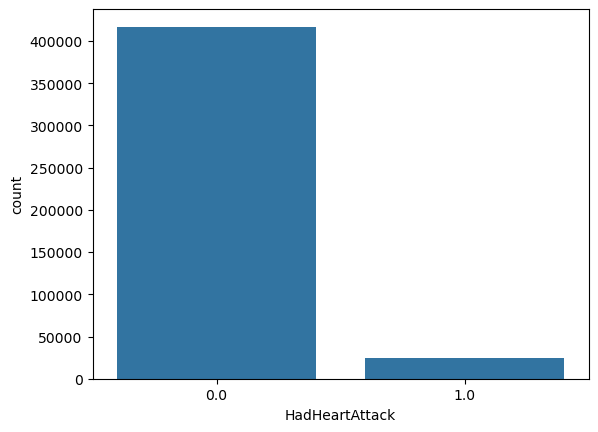

In [201]:
# Looking at Target "HadHeartAttack"
print(data_imputed['HadHeartAttack'].value_counts(normalize=True))
sns.countplot(x='HadHeartAttack', data=data_imputed)
# we can see that there is a very heavy class imbalance and we will be accounting for 
# this by using the f1 score as a measure of model performance

### States

In [202]:
# Examining the 'State' feature
state_rates = (
    data_imputed.groupby("State", observed=False)["HadHeartAttack"]
    .agg(heart_attack_rate="mean", count="count")
    .reset_index()
)
state_rates["heart_attack_rate"] *= 100
us_state_to_abbrev = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "District of Columbia": "DC",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY",
    
    # BRFSS territories
    "Guam": "GU",
    "Puerto Rico": "PR",
    "Virgin Islands": "VI"
}

state_rates["abbr"] = (
    state_rates["State"]
    .map(us_state_to_abbrev)
)

state_rates = state_rates.sort_values('heart_attack_rate', ascending=False).reset_index(drop=True)

fig = px.choropleth(
    state_rates,
    locations="abbr",
    locationmode="USA-states",
    color="heart_attack_rate",
    scope="usa",
    color_continuous_scale="Reds",
    labels={
        "heart_attack_rate": "Heart Attack Rate (%)"
    },
    title="Heart Attack Prevalence by State"
)

fig.show()

fig = px.choropleth(
    state_rates,
    locations="abbr",
    locationmode="USA-states",
    color="count",
    scope="usa",
    color_continuous_scale="Blues",
    labels={
        "count": "count"
    },
    title="Number of data entries by State"
)

fig.show()

# state_rates.sort_values('heart_attack_rate', ascending=False).reset_index(drop=True)

In [203]:
state_to_region = {
    # Northeast
    "CT": "Northeast", "ME": "Northeast", "MA": "Northeast", "NH": "Northeast",
    "RI": "Northeast", "VT": "Northeast", "NJ": "Northeast", "NY": "Northeast", "PA": "Northeast",

    # Midwest
    "IL": "Midwest", "IN": "Midwest", "MI": "Midwest", "OH": "Midwest", "WI": "Midwest",
    "IA": "Midwest", "KS": "Midwest", "MN": "Midwest", "MO": "Midwest", "NE": "Midwest",
    "ND": "Midwest", "SD": "Midwest",

    # South
    "DE": "South", "FL": "South", "GA": "South", "MD": "South", "NC": "South",
    "SC": "South", "VA": "South", "DC": "South", "WV": "South",
    "AL": "South", "KY": "South", "MS": "South", "TN": "South",
    "AR": "South", "LA": "South", "OK": "South", "TX": "South",

    # West
    "AZ": "West", "CO": "West", "ID": "West", "MT": "West", "NV": "West",
    "NM": "West", "UT": "West", "WY": "West",
    "AK": "West", "CA": "West", "HI": "West",
    "OR": "West", "WA": "West"
}

state_rates["Region"] = state_rates["abbr"].map(state_to_region)

state_rates
# data_imputed["Region"] = data_imputed["State"].map(state_to_region) # only if regional is useful

,State,heart_attack_rate,count,abbr,Region
0,WV,8.978766,4945,NaN,NaN
1,AR,8.662469,5241,NaN,NaN
2,FL,7.664508,13282,NaN,NaN
3,NH,7.456010,6706,NaN,NaN
4,OK,7.219204,5707,NaN,NaN
5,KY,7.217782,4004,NaN,NaN
6,TN,7.088269,5234,NaN,NaN
7,ME,7.086168,10584,NaN,NaN
8,AZ,7.017544,10089,NaN,NaN
9,AL,6.972067,4475,NaN,NaN


In [204]:
import plotly.express as px

fig = px.choropleth(
    state_rates,
    locations="abbr",          # state abbreviations (CA, TX, etc.)
    locationmode="USA-states",
    color="Region",            # color by region instead of numeric value
    scope="usa",
    hover_name="State",
    hover_data={
        "heart_attack_rate": ":.2%",
        "Region": True,
        "abbr": False
    },
    title="Heart Attack Rate by State (Colored by Region)"
)

fig.update_layout(
    geo=dict(showlakes=True),
)

fig.show()

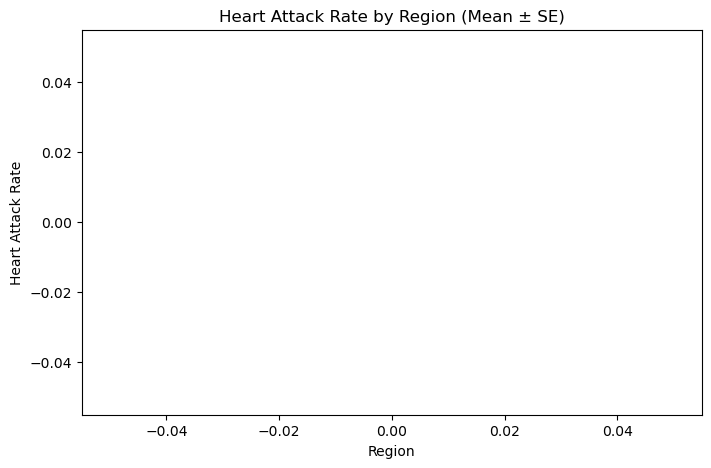

In [205]:
region_summary = (
    state_rates.groupby("Region")["heart_attack_rate"]
    .agg(mean="mean", std="std", count="count")
    .reset_index()
)

region_summary["se"] = region_summary["std"] / np.sqrt(region_summary["count"])
region_summary

plt.figure(figsize=(8,5))

plt.bar(
    region_summary["Region"],
    region_summary["mean"],
    yerr=region_summary["se"],
    capsize=5,
    color=['#AA62FA', '#EF553B', '#5C63CD', '#04CB97']
)

plt.title("Heart Attack Rate by Region (Mean ± SE)")
plt.ylabel("Heart Attack Rate")
plt.xlabel("Region")

plt.show()

/var/folders/d2/b6r3bd092gd64r62_0p_5mbm0000gn/T/ipykernel_8903/2215386374.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/d2/b6r3bd092gd64r62_0p_5mbm0000gn/T/ipykernel_8903/2215386374.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.boxplot(


UnboundLocalError: cannot access local variable 'boxprops' where it is not associated with a value

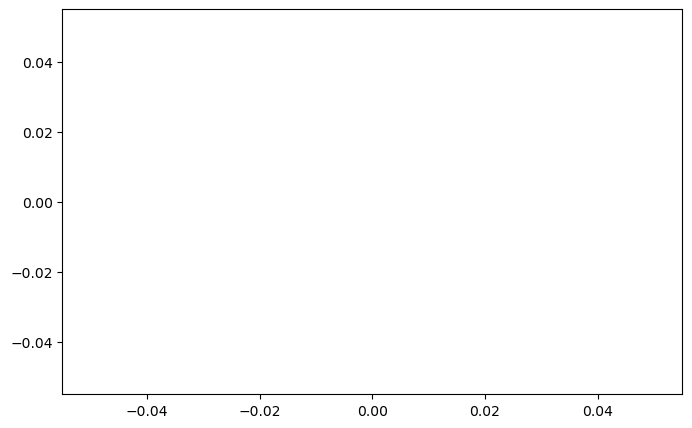

In [206]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=state_rates,
    x="Region",
    y="heart_attack_rate",
    palette=['#AA62FA', '#EF553B', '#5C63CD', '#04CB97']
)

plt.title("Heart Attack Rate Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Heart Attack Rate")

plt.show()

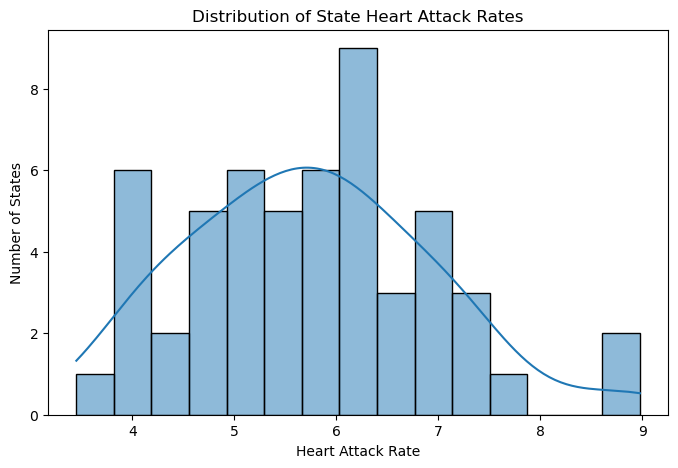

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(state_rates["heart_attack_rate"], bins=15, kde=True)

plt.title("Distribution of State Heart Attack Rates")
plt.xlabel("Heart Attack Rate")
plt.ylabel("Number of States")

plt.show()

In [ ]:
overall_stats = {
    "mean": state_rates["heart_attack_rate"].mean(),
    "median": state_rates["heart_attack_rate"].median(),
    "std": state_rates["heart_attack_rate"].std(),
    "IQR": state_rates["heart_attack_rate"].quantile(0.75)
         - state_rates["heart_attack_rate"].quantile(0.25)
}

overall_stats

{'mean': 5.75141476379904,
 'median': 5.721564479212209,
 'std': 1.1939521135575413,
 'IQR': 1.5211612318500132}

In [ ]:
region_stats = state_rates.groupby("Region")["heart_attack_rate"].agg(
    mean="mean",
    median="median",
    std="std",
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75)
)

region_stats

,mean,median,std,q25,q75
Region,,,,,
Midwest,5.834334,6.040182,0.875175,5.555188,6.407403
Northeast,5.455182,5.265467,1.140493,4.635882,5.729434
South,6.356709,6.155189,1.390760,5.402844,7.217782
West,5.303052,5.218505,1.010406,4.307787,6.090429


### Categorical, Continous, and Missingness Column Analysis

In [ ]:
continous_cols = []
for col in data_imputed.columns:
    if data_imputed[col].unique().size > 15:
        # print(f'------- {col} --------')
        # print(f'num unique = {data_imputed[col].unique().size}')
        # print(f'values = { ", ".join(str(x) for x in data_imputed[col].unique()) }')
        continous_cols += [col]


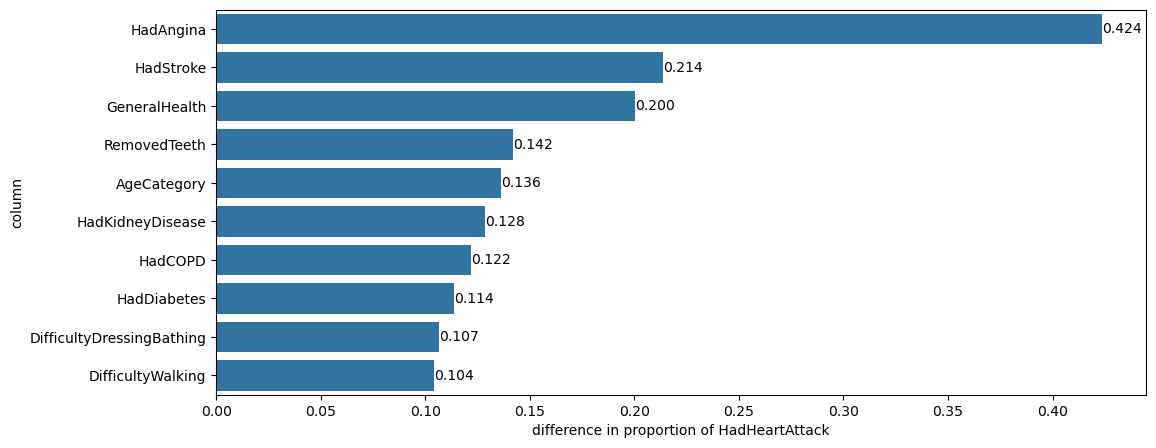

In [ ]:
categorical_cols = ['State', 'Sex', 'GeneralHealth', 'LastCheckupTime', 'PhysicalActivities',
       'RemovedTeeth', 'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
       'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 
       'DeafOrHardOfHearing', 'BlindOrVisionDifficulty', 'DifficultyConcentrating', 
       'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands', 
       'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory', 'AgeCategory',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap',
       'HighRiskLastYear', 'CovidPos']

continous_cols = ['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours', 
                  'HeightInMeters', 'WeightInKilograms', 'BMI']

missingness_cols = ['GeneralHealthmissing', 'PhysicalHealthDaysmissing', 
                    'MentalHealthDaysmissing', 'LastCheckupTimemissing', 
                    'PhysicalActivitiesmissing', 'SleepHoursmissing',
                    'RemovedTeethmissing', 'HadAnginamissing','HadStrokemissing', 
                    'HadAsthmamissing', 'HadSkinCancermissing', 'HadCOPDmissing', 
                    'HadDepressiveDisordermissing', 'HadKidneyDiseasemissing', 
                    'HadArthritismissing', 'HadDiabetesmissing', 
                    'DeafOrHardOfHearingmissing', 'BlindOrVisionDifficultymissing',
                    'DifficultyConcentratingmissing', 'DifficultyWalkingmissing',
                    'DifficultyDressingBathingmissing', 'DifficultyErrandsmissing',
                    'SmokerStatusmissing', 'ECigaretteUsagemissing', 'ChestScanmissing',
                    'AgeCategorymissing', 'HeightInMetersmissing','WeightInKilogramsmissing', 
                    'BMImissing', 'AlcoholDrinkersmissing', 'HIVTestingmissing', 
                    'FluVaxLast12missing', 'PneumoVaxEvermissing',
                    'HighRiskLastYearmissing', 'CovidPosmissing']
diff_greater_than_10 = {}

for col in categorical_cols:
    grouped_proportions = data_imputed.groupby(col, observed=False)["HadHeartAttack"]\
        .apply(lambda x: (x == 1).mean()).sort_values()
    diff = grouped_proportions.iloc[-1] - grouped_proportions.iloc[0]
    
    
    if diff > 0.10:
        # print(f"{col} difference = {diff}")
        # sns.histplot(
        #     data=data_imputed,
        #     x=col,
        #     hue="HadHeartAttack",
        #     stat="density",
        #     common_norm=False
        # )
        diff_greater_than_10[col] = diff

proportion_diff_df = (
    pd.Series(diff_greater_than_10, name="difference in proportion of HadHeartAttack")
      .rename_axis("column")
      .reset_index()
      .sort_values("difference in proportion of HadHeartAttack", ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    y='column',
    x='difference in proportion of HadHeartAttack',
    data=proportion_diff_df,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')  # 3 decimal places
# plt.xticks(rotation=10, ha='right')  # tilt labels
# plt.tight_layout()                   # prevent cutoff
plt.show()

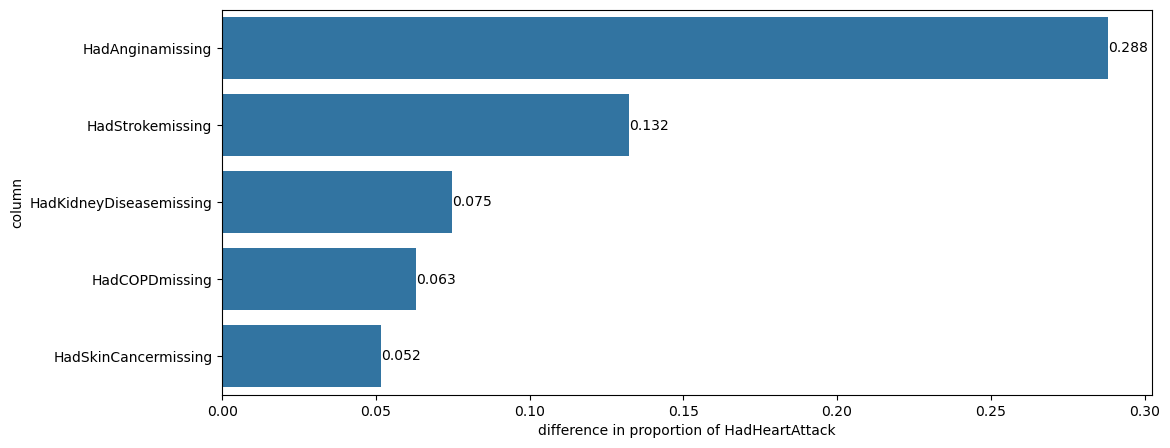

In [ ]:
diff_greater_than_5 = {}

for col in missingness_cols:
    grouped_proportions = data_imputed.groupby(col, observed=False)["HadHeartAttack"]\
        .apply(lambda x: (x == 1).mean()).sort_values()
    diff = grouped_proportions.iloc[-1] - grouped_proportions.iloc[0]
    
    
    if diff > 0.05:
        # print(f"{col} difference = {diff}")
        # sns.histplot(
        #     data=data_imputed,
        #     x=col,
        #     hue="HadHeartAttack",
        #     stat="density",
        #     common_norm=False
        # )
        diff_greater_than_5[col] = diff

missingness_proportion_diff_df = (
    pd.Series(diff_greater_than_5, name="difference in proportion of HadHeartAttack")
      .rename_axis("column")
      .reset_index()
      .sort_values("difference in proportion of HadHeartAttack", ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    y='column',
    x='difference in proportion of HadHeartAttack',
    data=missingness_proportion_diff_df,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')  # 3 decimal places
# plt.xticks(rotation=30, ha='right')  # tilt labels
# plt.tight_layout()                   # prevent cutoff
plt.show()

In [ ]:
def plot_hist_with_stats(df, value_col, hue_col, bins=25):
    plt.figure(figsize=(10, 6))

    # Histogram
    sns.histplot(
        data=df,
        x=value_col,
        hue=hue_col,
        bins=bins,
        stat="density",
        common_norm=False,
        alpha=0.4,
        palette=["red", "blue"]
    )

    # Mean/Median lines
    for group, color in zip(sorted(df[hue_col].dropna().unique()), ['red', 'blue']):
        vals = df.loc[df[hue_col] == group, value_col].dropna()
        if group == 1:
            ha = "had heart attack"
        else:
            ha="no heart attack"
        mean = vals.mean()
        median = vals.median()

        plt.axvline(
            mean,
            linestyle="--",
            linewidth=2,
            label=f"{ha} Mean",
            color = color
        )

        # plt.axvline(
        #     median,
        #     linestyle=":",
        #     linewidth=2,
        #     label=f"{group} Median",
        #     color = color
        # )

    plt.title(f"{value_col} by {hue_col}")
    plt.legend()
    plt.show()

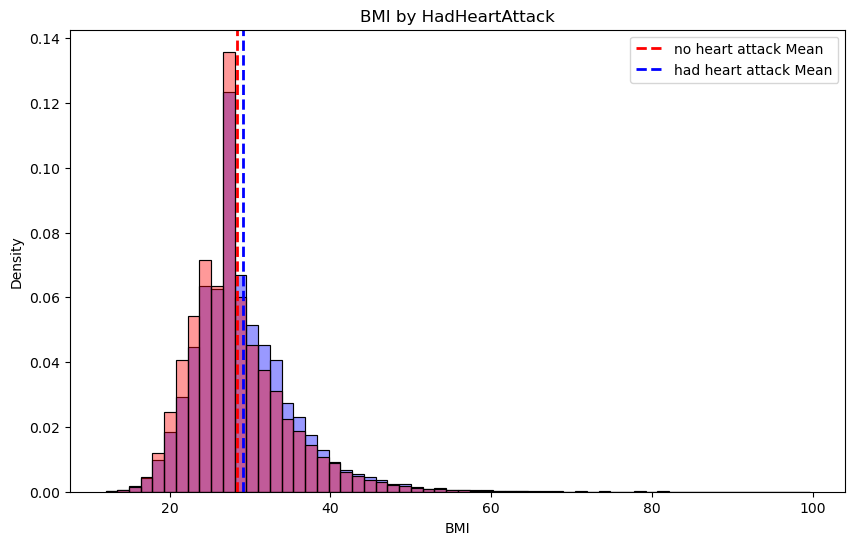

In [ ]:
plot_hist_with_stats(
    data_imputed,
    value_col="BMI",
    hue_col="HadHeartAttack",
    bins=60
)

In [ ]:
pd.qcut(data_imputed["BMI"], q=10)

0          (26.63, 27.44]
1          (25.11, 26.63]
2          (25.11, 26.63]
3          (21.79, 23.71]
4         (12.019, 21.79]
               ...       
445127     (25.11, 26.63]
445128     (28.19, 29.95]
445129    (12.019, 21.79]
445130     (32.28, 36.26]
445131     (21.79, 23.71]
Name: BMI, Length: 442067, dtype: category
Categories (10, interval[float64, right]): [(12.019, 21.79] < (21.79, 23.71] < (23.71, 25.11] < (25.11, 26.63] ... (28.19, 29.95] < (29.95, 32.28] < (32.28, 36.26] < (36.26, 99.64]]

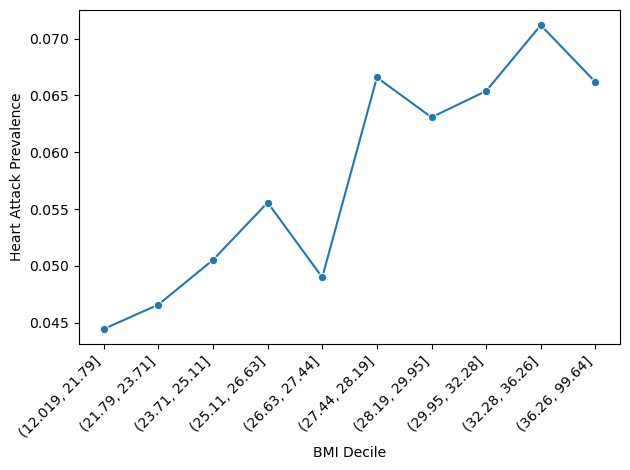

In [ ]:
df = data_imputed.copy()

df["BMI_bin"] = pd.qcut(df["BMI"], q=10)

prevalence = (
    df.groupby("BMI_bin", observed=False)["HadHeartAttack"]
      .mean()
      .reset_index()
)

prevalence["BMI_bin"] = prevalence["BMI_bin"].astype(str)

sns.lineplot(
    data=prevalence,
    x="BMI_bin",
    y="HadHeartAttack",
    marker="o"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Heart Attack Prevalence")
plt.xlabel("BMI Decile")
plt.tight_layout()
plt.show()

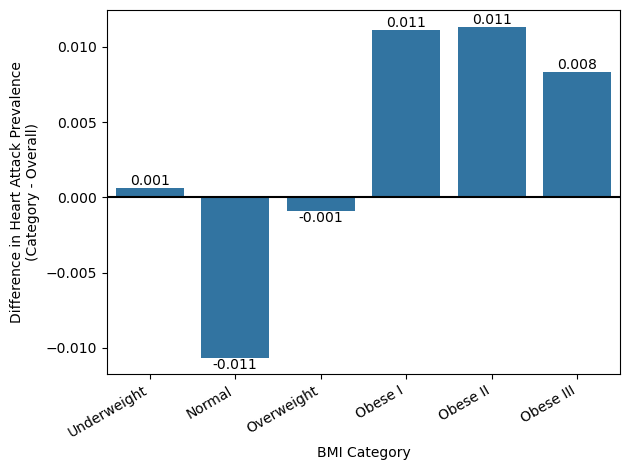

In [ ]:
df = data_imputed.copy()
data_prop_ha = data_imputed["HadHeartAttack"].mean()

df["BMI_category"] = pd.cut(
    df["BMI"],
    bins=[0, 18.5, 25, 30, 35, 40, np.inf],
    labels=[
        "Underweight", "Normal", "Overweight",
        "Obese I", "Obese II", "Obese III"
    ]
)

prevalence = (
    df.groupby("BMI_category", observed=False)["HadHeartAttack"]
      .mean()
      .reset_index()
      .rename(columns={"HadHeartAttack": "category_rate"})
)

overall = data_imputed["HadHeartAttack"].mean()

prevalence["diff_vs_overall"] = prevalence["category_rate"] - overall
prevalence["pct_change_vs_overall"] = (
    (prevalence["category_rate"] - overall) / overall
) * 100

ax = sns.barplot(
    data=prevalence,
    x="BMI_category",
    y="diff_vs_overall",
)

ax.axhline(0, color="black")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.xticks(rotation=30, ha="right")

plt.ylabel("Difference in Heart Attack Prevalence\n(Category - Overall)")
plt.xlabel("BMI Category")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

# Models
We will be evaluating our models with F1 scores to account for the unequal sizes of the two target categories

In [207]:
# imports for modeling
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

## Preproc, test train split

In [209]:
X = data_imputed.drop(columns=["HadHeartAttack"])
y = data_imputed[["HadHeartAttack"]]

In [216]:
# OHE categorical columns, StandardScaler numerical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), 
            continous_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), 
            ['State', 'Sex', 'RaceEthnicityCategory', 'TetanusLast10Tdap']),
    ], 
    remainder="passthrough"
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
])

X_OHE = pipeline.fit_transform(X)

feature_names = pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

X_OHE = pd.DataFrame(
    X_OHE,
    columns=feature_names,
    index=X.index
)
X_OHE.head(5)

,num__PhysicalHealthDays,num__MentalHealthDays,num__SleepHours,num__HeightInMeters,num__WeightInKilograms,num__BMI,cat__State_AL,cat__State_AR,cat__State_AZ,cat__State_CA,...,remainder__DifficultyErrandsmissing,remainder__ChestScanmissing,remainder__HeightInMetersmissing,remainder__WeightInKilogramsmissing,remainder__BMImissing,remainder__AlcoholDrinkersmissing,remainder__HIVTestingmissing,remainder__FluVaxLast12missing,remainder__PneumoVaxEvermissing,remainder__HighRiskLastYearmissing
0,-0.49153,-0.515488,0.656772,-0.024913,-0.103725,-0.156524,1.0,0.0,0.0,0.0,...,False,False,True,True,True,False,False,False,False,False
1,-0.49153,-0.515488,-0.687687,-0.98944,-0.725653,-0.296994,1.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
2,-0.258523,-0.154541,-1.359916,-1.278798,-0.94798,-0.451996,1.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,-0.49153,-0.515488,-0.015457,-0.507176,-0.94798,-0.824968,1.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
4,-0.258523,-0.515488,1.329001,-1.278798,-1.414181,-1.072001,1.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False


In [217]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), continous_cols),
    ],
    remainder="passthrough"
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
])

X_standard_scaler = pipeline.fit_transform(X)

feature_names = pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

X_standard_scaler = pd.DataFrame(
    X_standard_scaler,
    columns=feature_names,
    index=X.index
)

X_standard_scaler.head(5)

,num__PhysicalHealthDays,num__MentalHealthDays,num__SleepHours,num__HeightInMeters,num__WeightInKilograms,num__BMI,remainder__State,remainder__Sex,remainder__GeneralHealth,remainder__LastCheckupTime,...,remainder__DifficultyErrandsmissing,remainder__ChestScanmissing,remainder__HeightInMetersmissing,remainder__WeightInKilogramsmissing,remainder__BMImissing,remainder__AlcoholDrinkersmissing,remainder__HIVTestingmissing,remainder__FluVaxLast12missing,remainder__PneumoVaxEvermissing,remainder__HighRiskLastYearmissing
0,-0.49153,-0.515488,0.656772,-0.024913,-0.103725,-0.156524,AL,Female,Very good,Within past year (anytime less than 12 months ...,...,False,False,True,True,True,False,False,False,False,False
1,-0.49153,-0.515488,-0.687687,-0.98944,-0.725653,-0.296994,AL,Female,Excellent,nan,...,False,False,False,False,False,False,False,False,False,False
2,-0.258523,-0.154541,-1.359916,-1.278798,-0.94798,-0.451996,AL,Female,Very good,Within past year (anytime less than 12 months ...,...,False,False,False,False,False,False,False,False,False,False
3,-0.49153,-0.515488,-0.015457,-0.507176,-0.94798,-0.824968,AL,Female,Excellent,Within past year (anytime less than 12 months ...,...,False,False,False,False,False,False,False,False,False,False
4,-0.258523,-0.515488,1.329001,-1.278798,-1.414181,-1.072001,AL,Female,Fair,Within past year (anytime less than 12 months ...,...,False,False,False,False,False,False,False,False,False,False


### Logistical Columns with ALL columns transformed numerically (OHE, mapping)

## Different Models
We will be experimenting with KNN, Logistical Regression, Random Forest, CapBoost, ensemble model, XGBoost / LightGBM. 

We will be using logistical regression as the baseline model

In [ ]:
imputed_df_numeric = df.copy()
imputed_df_numeric['HadHeartAttack'] = imputed_df_numeric['HadHeartAttack'].astype('Int64')
imputed_df_numeric = imputed_df_numeric.select_dtypes(include='number')

imputed_df_numeric = imputed_df_numeric.dropna()


# Split features and target
X1 = imputed_df_numeric.drop(columns=['HadHeartAttack'])
y1 = imputed_df_numeric['HadHeartAttack']

# Train/val/test split (80/10/10)
X1_train, X1_temp, y1_train, y1_temp = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)
X1_val, X1_test, y1_val, y1_test = train_test_split(
    X1_temp, y1_temp, test_size=0.5, random_state=42, stratify=y1_temp
)

# Scale features
scaler1 = StandardScaler()
X1_train = scaler1.fit_transform(X1_train)
X1_val = scaler1.transform(X1_val)
X1_test = scaler1.transform(X1_test)

# Fit model
model1 = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model1.fit(X1_train, y1_train)

# Evaluate on validation set
print("=== [Block 1] Validation Set ===")
y1_val_pred = model1.predict(X1_val)
y1_val_prob = model1.predict_proba(X1_val)[:, 1]
print(classification_report(y1_val, y1_val_pred))
print("Confusion Matrix:\n", confusion_matrix(y1_val, y1_val_pred))
print("ROC-AUC Score:", roc_auc_score(y1_val, y1_val_prob))

print("_________________________________________________________________\n")

# Evaluate on test set
print("=== [Block 1] Test Set ===")
y1_test_pred = model1.predict(X1_test)
y1_test_prob = model1.predict_proba(X1_test)[:, 1]
print(classification_report(y1_test, y1_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y1_test, y1_test_pred))
print("ROC-AUC Score:", roc_auc_score(y1_test, y1_test_prob))

## Hyper Parameter Tuning